In [1]:
library(DESeq2)
library(SummarizedExperiment)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics




Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package

In [2]:
featurecounts <- read.table("/usr/users/papantonis1/aman/rnaseq_data/irnaseq_results/all_samples_counts.txt", header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# Extract *only* count columns — from column 9 onwards
counts_introns <- featurecounts[, 9:ncol(featurecounts)]

# Rename columns to match samples
colnames(counts_introns) <- c("S55", "S56", "S57", "S58", "S59", "S60")

# Set rownames to gene symbols (or RefSeq if preferred)
rownames(counts_introns) <- featurecounts$Symbol

counts_introns

,S55,S56,S57,S58,S59,S60
,<int>,<int>,<int>,<int>,<int>,<int>
NAT2,22,18,0,0,0,0
ACAT1,205,258,839,750,748,634
SGCA,18,15,4,0,0,4
ADRB3,0,4,0,0,0,0
ABCD1,143,157,668,543,594,516
ALDOB,0,2,0,0,0,0
APOC3,6,17,0,0,0,0
APOH,10,0,0,0,2,0
FAS,155,147,587,497,691,596


In [3]:
dim(counts_introns)

[1] 14665     6

In [4]:
colnames(counts_introns)

[1] "S55" "S56" "S57" "S58" "S59" "S60"

In [5]:
condition <- factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control"),
                    levels = c("control", "CPI", "AuxinCPI"))

# control is the reference level

In [6]:
coldata <- data.frame(row.names = colnames(counts_introns),
                      condition = condition)
coldata

,condition
,<fct>
S55,AuxinCPI
S56,AuxinCPI
S57,CPI
S58,CPI
S59,control
S60,control


In [7]:
dds <- DESeqDataSetFromMatrix(countData = counts_introns,
                              colData = coldata,
                              design = ~ condition)

# design formula - gene expression based on the levels of the condition factor.

In [8]:
dds$condition <- relevel(dds$condition, ref = "control")
# Setting the reference level of the factor condition in the dds object to "control"

In [9]:
levels(dds$condition)

[1] "control"  "CPI"      "AuxinCPI"

In [10]:
dds <- DESeq(dds)
res <- results(dds, contrast = c("condition", "CPI", "control"))
res

# Fitting the negative binomial model and wald test for each gene comparing CPI vs control

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 14665 rows and 6 columns
       baseMean log2FoldChange     lfcSE       stat    pvalue      padj
      <numeric>      <numeric> <numeric>  <numeric> <numeric> <numeric>
NAT2   14.41197       0.000000  2.419770  0.0000000  1.000000        NA
ACAT1 501.71121       0.272218  0.201593  1.3503379  0.176908  0.731617
SGCA   12.79735      -0.171213  1.814003 -0.0943841  0.924804        NA
ADRB3   1.37112       0.000000  4.997455  0.0000000  1.000000        NA
ABCD1 369.48605       0.187005  0.213395  0.8763329  0.380849  0.865047
...         ...            ...       ...        ...       ...       ...
SFXN4  593.4197      0.0634620  0.199302   0.318421  0.750165  0.971461
KRT39    0.0000             NA        NA         NA        NA        NA
TPM2    58.5518     -0.4427437  0.564998  -0.783620  0.433263        NA
RPLP1  828.4261      0.0762998  0.231882   0.329046  0.742121  0.969463
P

In [11]:
summary(res)


out of 13775 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 45, 0.33%
LFC < 0 (down)     : 74, 0.54%
outliers [1]       : 0, 0%
low counts [2]     : 5589, 41%
(mean count < 134)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



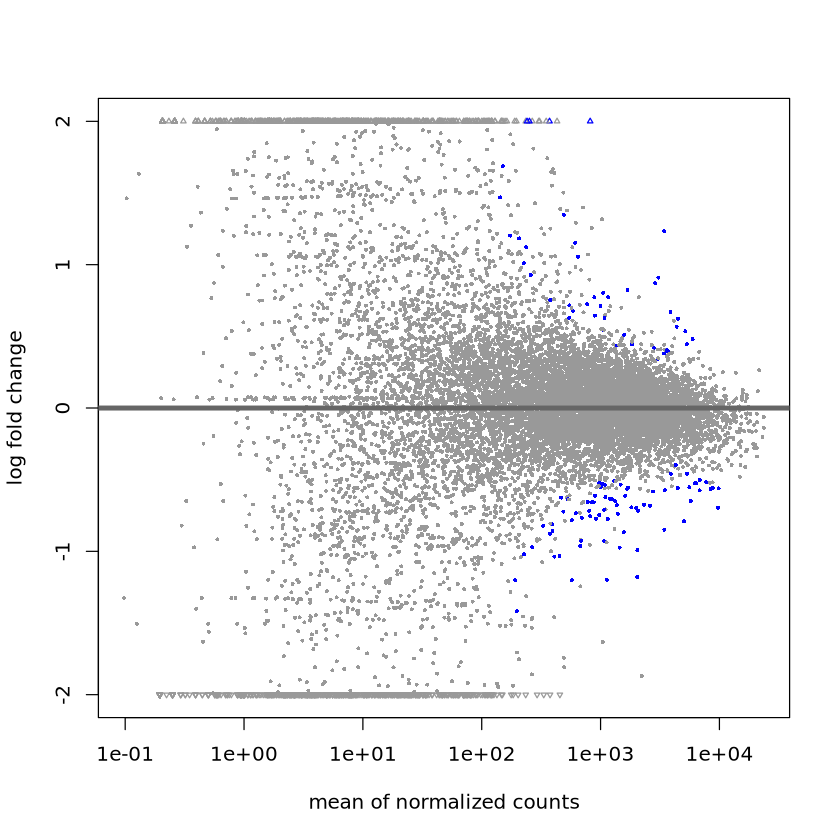

In [12]:
plotMA(res, ylim=c(-2,2))

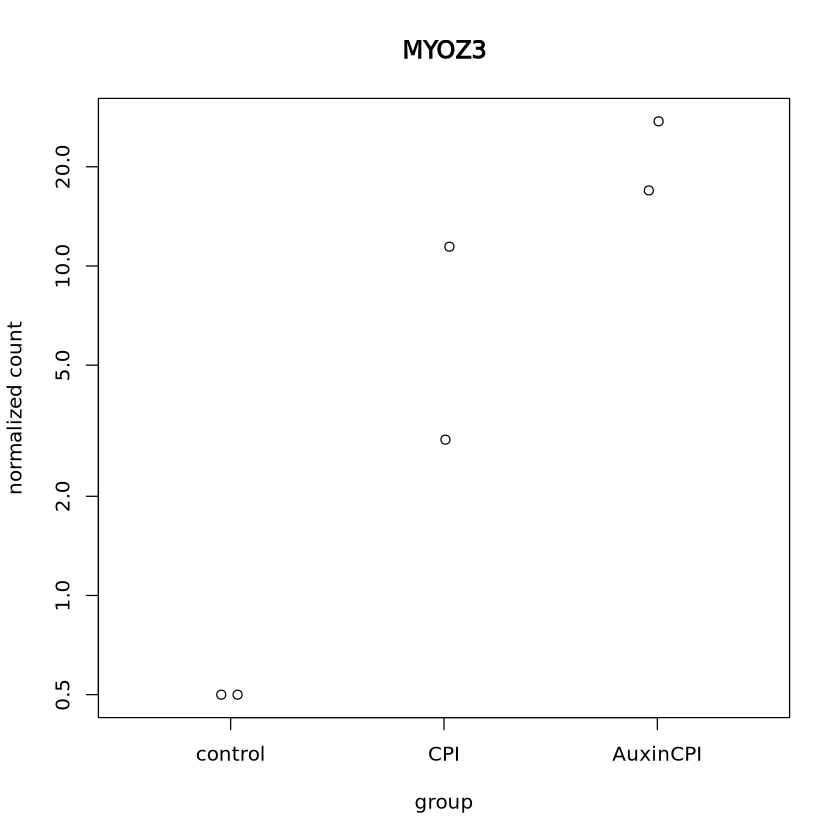

In [13]:
plotCounts(dds, gene=which.max(res$log2FoldChange), intgroup="condition")

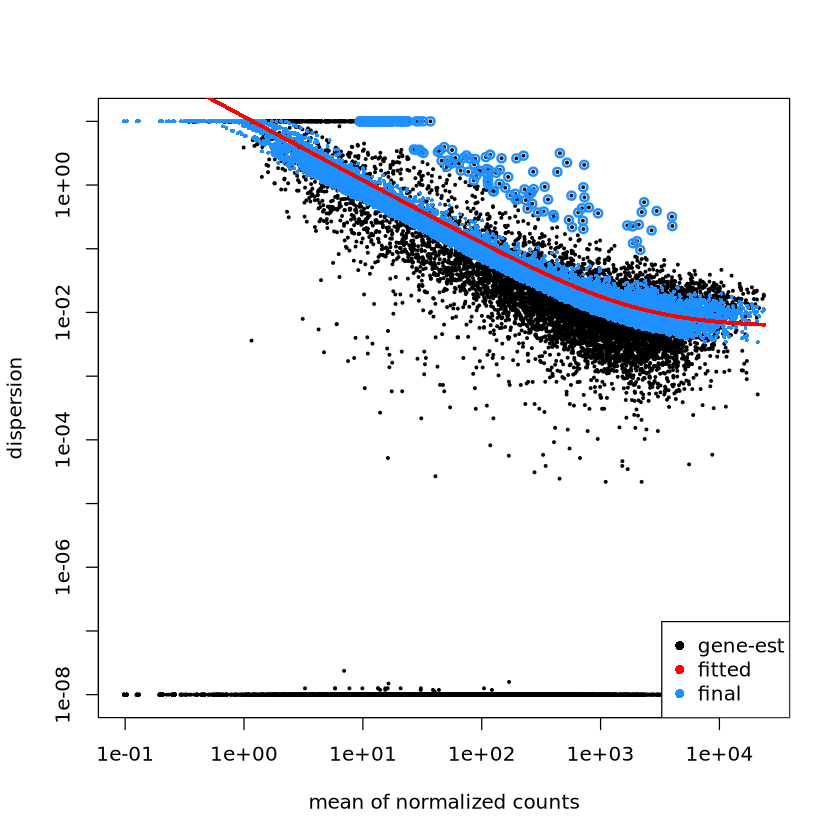

In [14]:
plotDispEsts(dds)

In [15]:
vsd <- vst(dds, blind=FALSE)

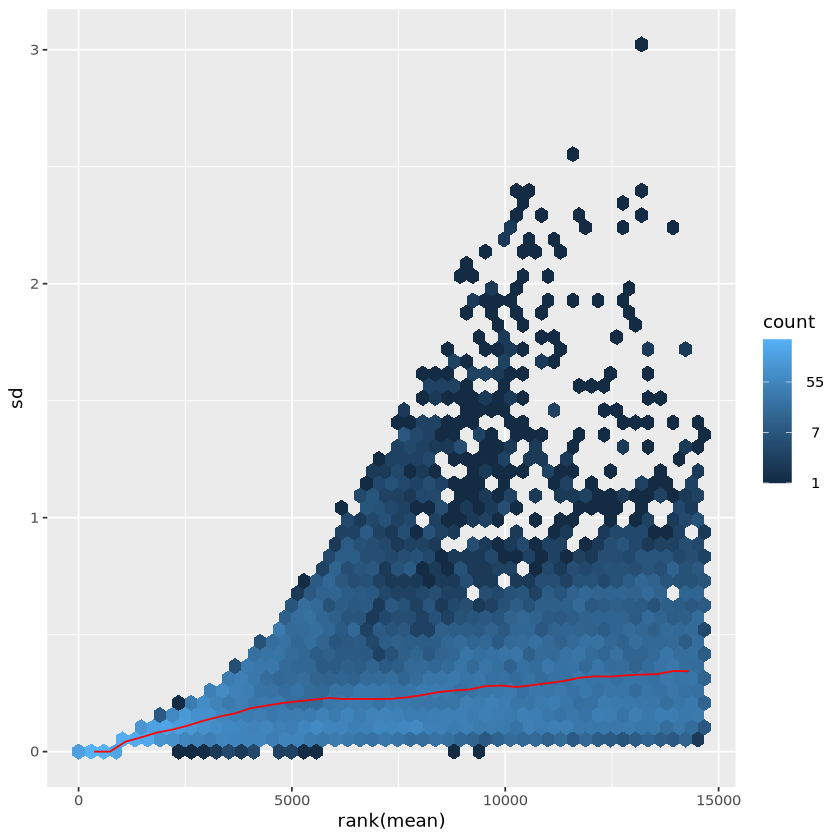

In [16]:
library("vsn")
meanSdPlot(assay(vsd))

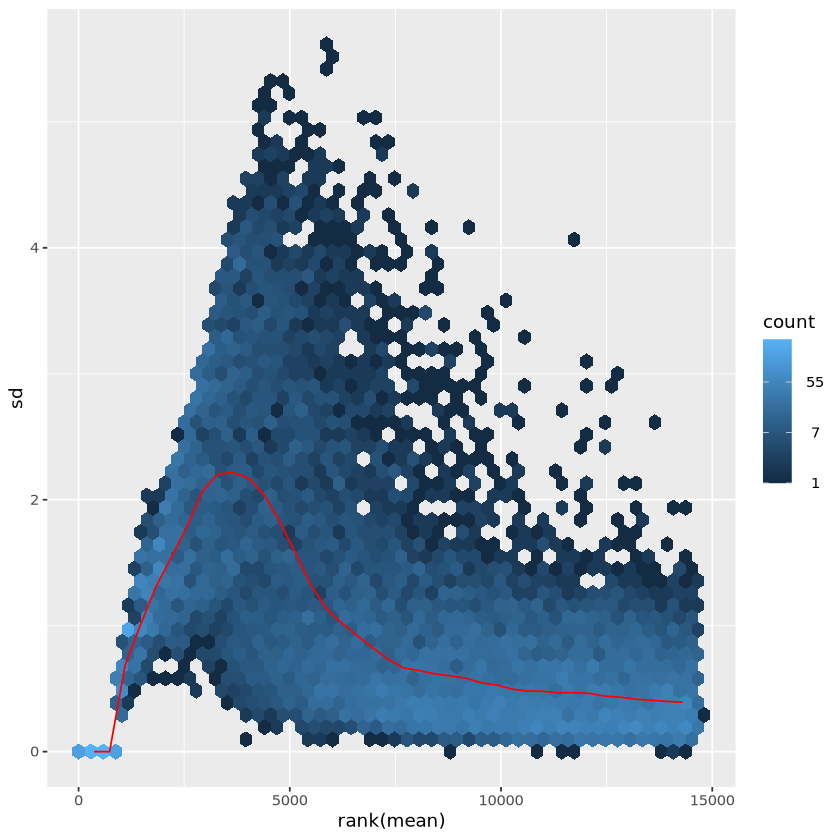

In [17]:
ntd <- normTransform(dds)
meanSdPlot(assay(ntd))

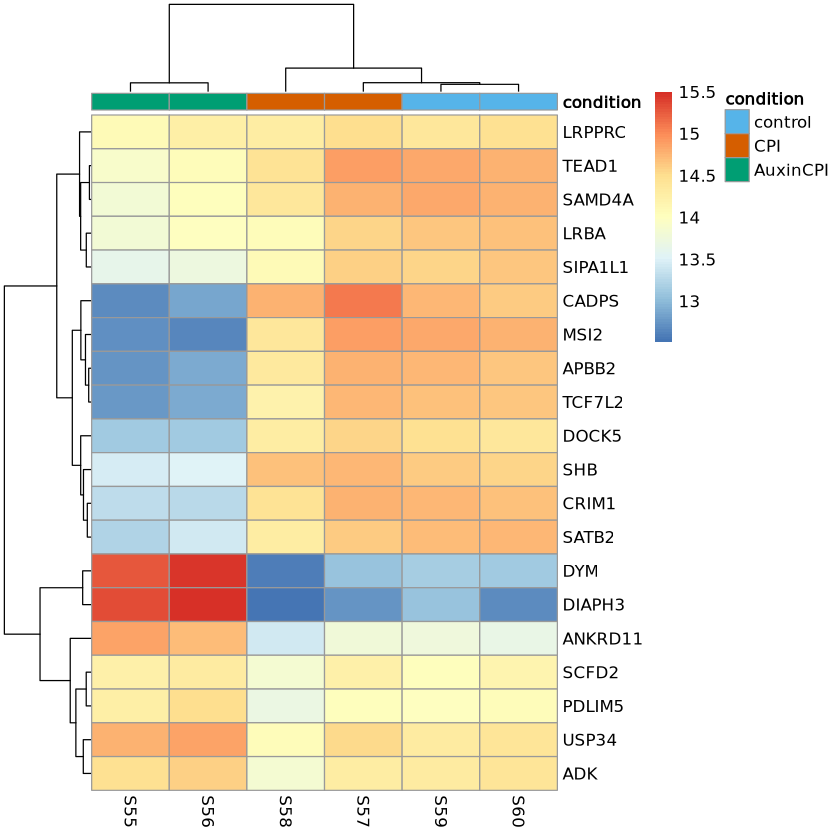

In [40]:
library("pheatmap")

select <- order(rowMeans(counts(dds, normalized=TRUE)), decreasing=TRUE)[1:20]


# Reassign colnames and ensure annotation matches order
colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
df <- as.data.frame(colData(dds)[, "condition", drop = FALSE])
rownames(df) <- colnames(vsd)
df$condition <- factor(df$condition, levels = c("control", "CPI", "AuxinCPI"))



# Define annotation colors
ann_colors <- list(
  condition = c("control" = "#56B4E9", "CPI" = "#D55E00", "AuxinCPI" = "#009E73")
)

pheatmap(
  assay(ntd)[select, ],
  cluster_rows = TRUE,
  show_rownames = TRUE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)


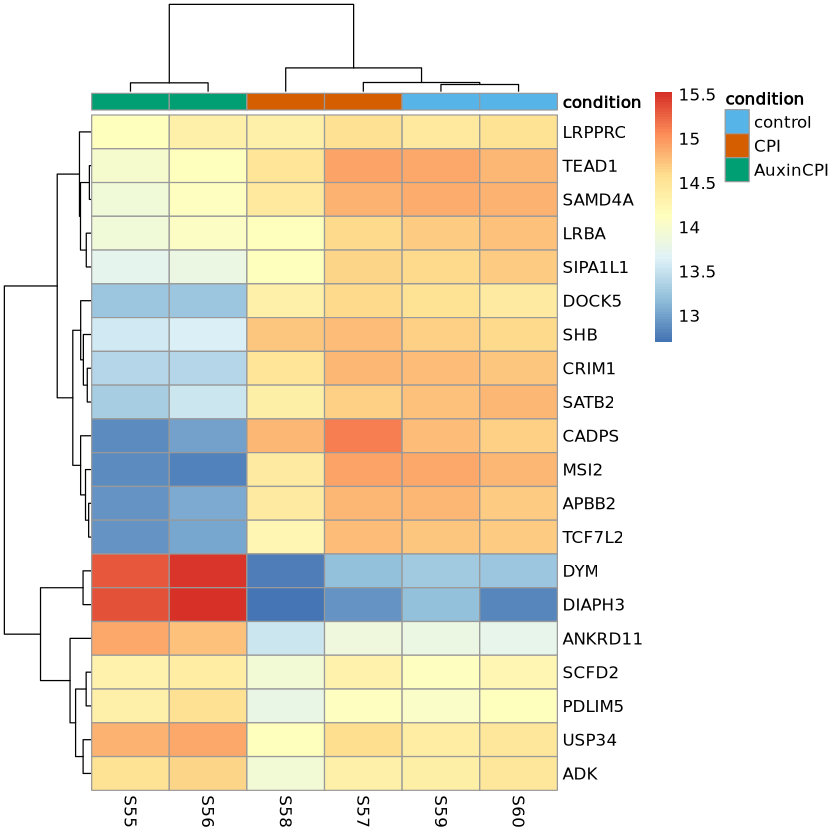

In [41]:
### VST

colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
pheatmap(
  assay(vsd)[select, ],
  cluster_rows = TRUE,
  show_rownames = TRUE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)

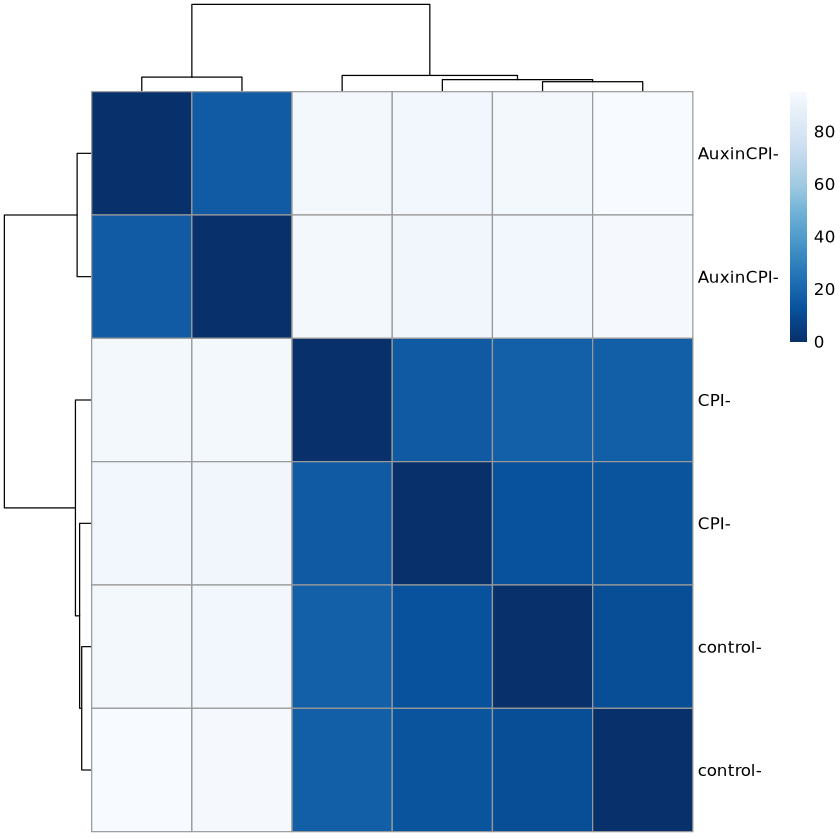

In [20]:
sampleDists <- dist(t(assay(vsd)))
library("RColorBrewer")
sampleDistMatrix <- as.matrix(sampleDists)
rownames(sampleDistMatrix) <- paste(vsd$condition, vsd$type, sep="-")
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows=sampleDists,
         clustering_distance_cols=sampleDists,
         col=colors)

# control and cpi correlated which in a way makes sense biologically

In [21]:
#plotPCA(vsd, intgroup=c("condition"))
pca <- prcomp(t(assay(vsd)))
summary(pca)


Importance of components:
                           PC1     PC2     PC3     PC4    PC5       PC6
Standard deviation     47.7413 6.26263 4.85499 3.98792 3.2662 7.574e-14
Proportion of Variance  0.9623 0.01656 0.00995 0.00671 0.0045 0.000e+00
Cumulative Proportion   0.9623 0.97883 0.98878 0.99550 1.0000 1.000e+00

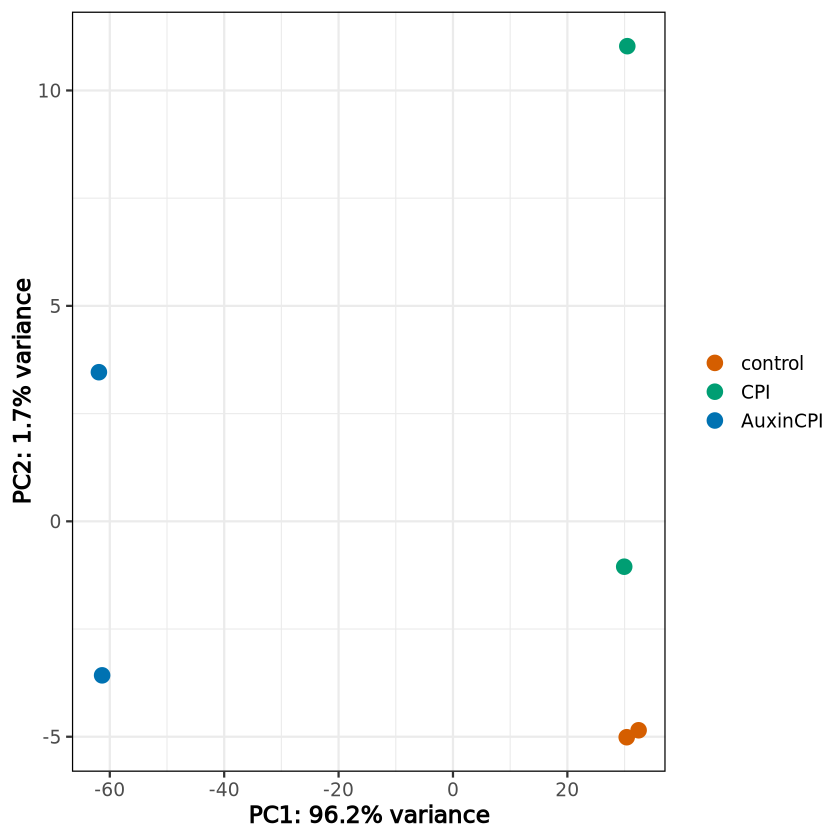

In [22]:
library(ggplot2)

# Extract PCA coordinates
pca_data <- as.data.frame(pca$x)
pca_data$condition <- colData(vsd)$condition  # Add condition info

# Variance labels
percentVar <- round(100 * summary(pca)$importance[2, 1:2], 1)

# Plot
ggplot(pca_data, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 4) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  theme_bw(base_size = 14) +
  scale_color_manual(values = c("control" = "#D55E00", "CPI" = "#009E73", "AuxinCPI" = "#0072B2")) +
  theme(
    panel.border = element_rect(color = "black", linewidth = 0.7),
    axis.title = element_text(face = "bold"),
    legend.title = element_blank()
  )


In [23]:
resultsNames(dds)

[1] "Intercept"                     "condition_CPI_vs_control"     
[3] "condition_AuxinCPI_vs_control"

In [24]:
resLFC <- lfcShrink(dds, coef="condition_CPI_vs_control", type="apeglm")
resLFC

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



log2 fold change (MAP): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 14665 rows and 5 columns
       baseMean log2FoldChange     lfcSE    pvalue      padj
      <numeric>      <numeric> <numeric> <numeric> <numeric>
NAT2   14.41197   -1.17993e-04 0.0775668  0.977982        NA
ACAT1 501.71121    3.96738e-02 0.0852960  0.176908  0.731617
SGCA   12.79735   -3.38569e-04 0.0774988  0.924804        NA
ADRB3   1.37112   -9.69588e-05 0.0775672  0.989349        NA
ABCD1 369.48605    2.27257e-02 0.0771153  0.380849  0.865047
...         ...            ...       ...       ...       ...
SFXN4  593.4197     0.00852406 0.0728563  0.750165  0.971461
KRT39    0.0000             NA        NA        NA        NA
TPM2    58.5518    -0.00819978 0.0774885  0.433263        NA
RPLP1  828.4261     0.00779067 0.0740641  0.742121  0.969463
PRR27    0.0000             NA        NA        NA        NA

In [25]:
# order based on the pval
resOrdered <- res[order(res$pvalue),]
resOrdered

log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 14665 rows and 6 columns
                 baseMean log2FoldChange     lfcSE      stat      pvalue
                <numeric>      <numeric> <numeric> <numeric>   <numeric>
LAMA5            5030.274      -0.791134  0.135604  -5.83417 5.40598e-09
SYCE2             489.856       1.348436  0.238713   5.64877 1.61602e-08
MMP24-AS1-EDEM2  3879.739       0.669093  0.125783   5.31941 1.04106e-07
GOSR2            5173.247       0.535390  0.101200   5.29043 1.22028e-07
FGFRL1            675.826      -0.962874  0.186858  -5.15297 2.56387e-07
...                   ...            ...       ...       ...         ...
DEFB132                 0             NA        NA        NA          NA
AMTN                    0             NA        NA        NA          NA
TMEM215                 0             NA        NA        NA          NA
KRT39                   0             NA        NA        NA  

In [26]:
# filtering with padj < 0.05
sum(res$padj < 0.05, na.rm=TRUE)

[1] 70

In [27]:
res_raw <- results(dds, contrast = c("condition", "CPI", "control"))

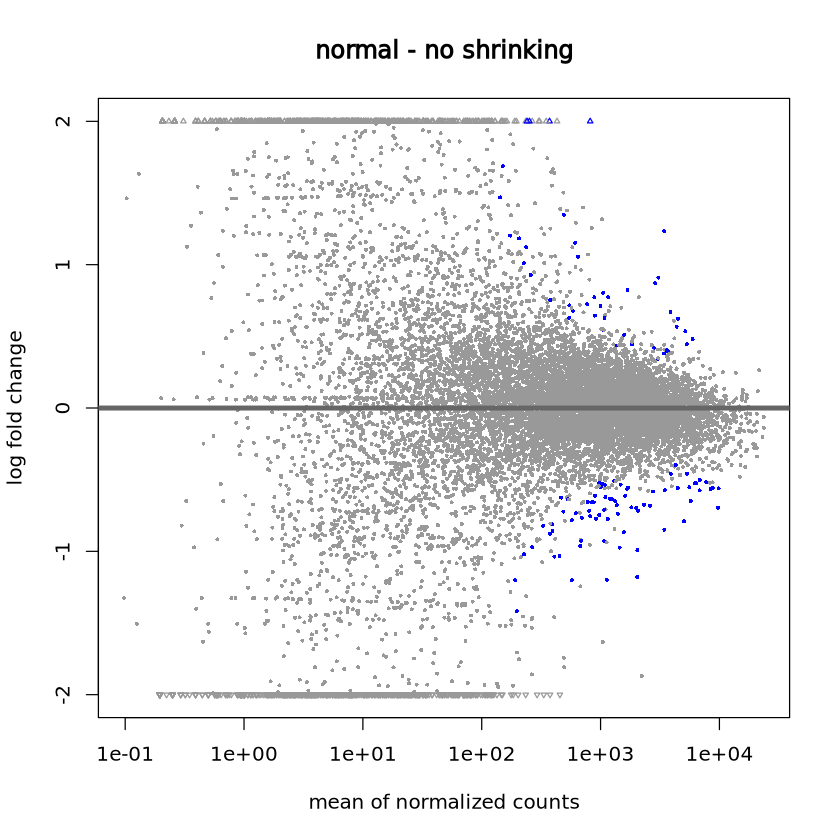

In [28]:
plotMA(res_raw, ylim=c(-2,2), main="normal - no shrinking")

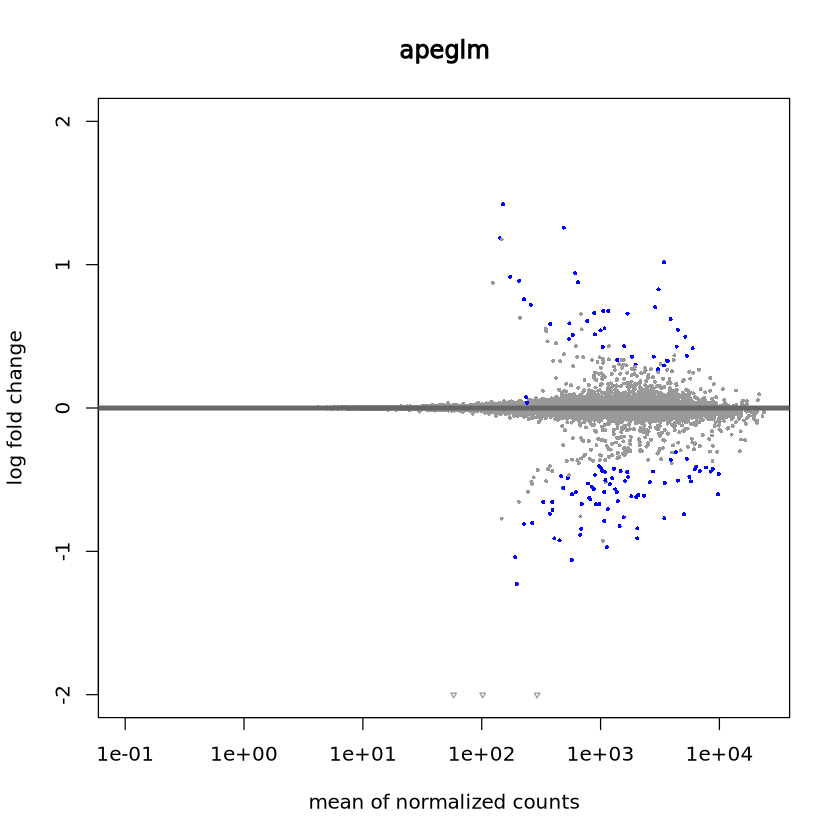

In [29]:
plotMA(resLFC, ylim=c(-2,2), main="apeglm")

In [30]:
sig_res <- res[which(res$padj < 0.05), ]

In [31]:
sig_res

log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 70 rows and 6 columns
           baseMean log2FoldChange     lfcSE      stat      pvalue        padj
          <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
PKD1       1396.136      -0.738047  0.170297  -4.33387 1.46510e-05 0.005996648
GAS6       1607.745      -0.612806  0.165919  -3.69340 2.21278e-04 0.032934145
FGFRL1      675.826      -0.962874  0.186858  -5.15297 2.56387e-07 0.000419757
NEURL4      392.768      -0.811724  0.228644  -3.55017 3.84984e-04 0.047749627
OR51B5      150.681       1.687818  0.437824   3.85502 1.15723e-04 0.022030337
...             ...            ...       ...       ...         ...         ...
ANKRD52    1088.284      -0.537223  0.147090  -3.65236 2.59845e-04  0.03565467
MICALL2     820.144      -0.755563  0.197415  -3.82728 1.29565e-04  0.02305696
RGS12      1702.742      -0.555398  0.136430  -4.07093 4.68250e-05  0.01161543

In [32]:
upregulated <- sig_res[which(sig_res$log2FoldChange > 0.6), ]
up_genes <- rownames(upregulated)

In [33]:
downregulated <- sig_res[which(sig_res$log2FoldChange < - 0.6), ]
down_genes <- rownames(downregulated)

In [34]:
length(up_genes)

[1] 17

In [35]:
length(down_genes)

[1] 37

In [36]:
up_df <- data.frame(
  ensembl = rownames(upregulated),
  log2FC = upregulated$log2FoldChange
)

write.table(up_df, file = "upregulated_genes_introns_irnaseqCM.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [37]:
down_df <- data.frame(
  ensembl = rownames(downregulated),
  log2FC = downregulated$log2FoldChange
)
write.table(down_df, file = "downregulated_genes_introns_irnaseqCM.txt", sep = "\t", quote = FALSE, row.names = FALSE)

Loading required package: ggrepel



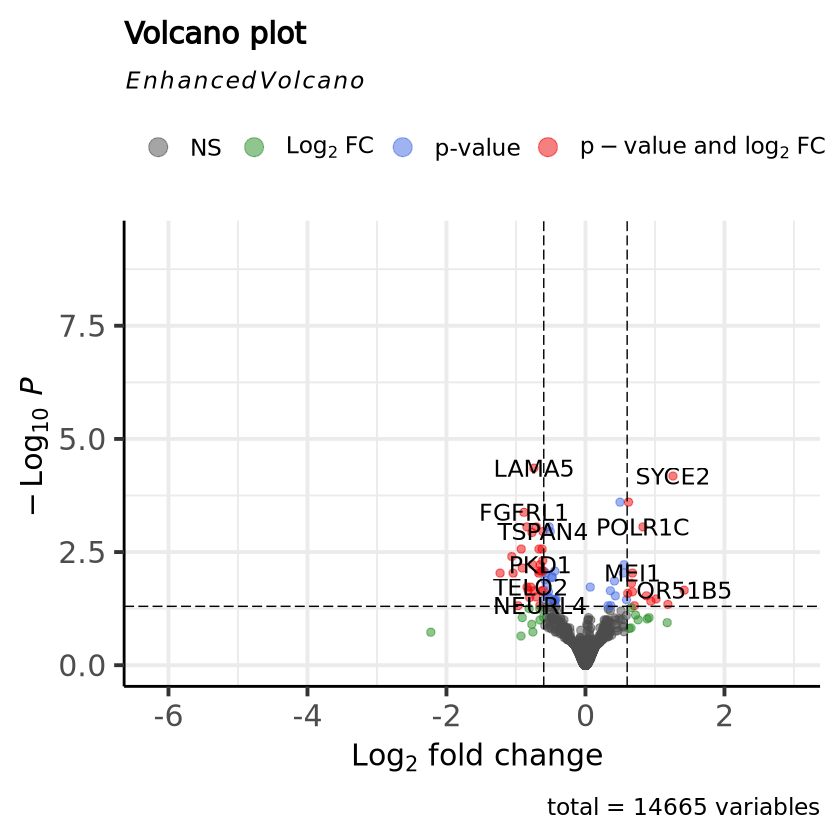

In [38]:
library(EnhancedVolcano)
EnhancedVolcano(resLFC,
  lab = rownames(resLFC),
  x = 'log2FoldChange',
  y = 'padj',
  pCutoff = 0.05,
  FCcutoff = 0.6)

# resLFC used as it is the shrunk one

In [39]:
# why more downregulation??